# Introduction to neural network classification with TensorFlow

In this notebook we're going to learn how to write neural networks for classification


A classification is where you try to classify something as one thing or another.
A few types of classification problems
* Binary classification
* Multiclass classification
* Multilabel classification

In [22]:
# Creating data to view and fit

from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000


# Create circles
X, y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)

In [23]:
#Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [24]:
# check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

our data is a little hard to understand right now... let's visualize it.

In [25]:
import pandas as pd

circles = pd.DataFrame({"X0": X[:,0], "X1": X[:, 1]})
circles

,X0,X1
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723
...,...,...
995,0.244054,0.944125
996,-0.978655,-0.272373
997,-0.136900,-0.810012
998,0.670362,-0.767502


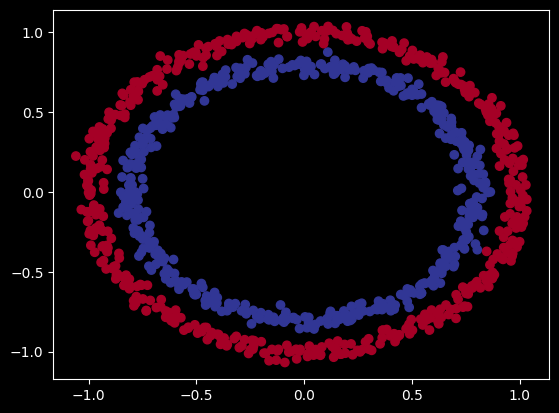

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

**🛠️ Exercise:** Before pushing forward, spend 10-minutes playing around with [playground.tensorflow.org](playground.tensorflow.org) building and running different neural networks. See what happens when you change different hyperparameters.


### Input and output shapes

In [27]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [28]:
# How many samples we're working
len(X), len(y)

(1000, 1000)

In [29]:
# View the first example of features and labels
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

## Steps in modeling
The steps in modeling with TensorFlow are typically:
1. Create or import a model
2. Compile the model
3. Fit the model
4. Evaluate the model
5. Tweak
6. Evaluate..

In [30]:
# Import TensorFlow
import tensorflow as tf
tf.__version__

'2.21.0'

In [31]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

# 3. Fit the model
model_1.fit(X,y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 5.9236   
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 5.8878 
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 5.8467 
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4840 - loss: 5.8335 
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4840 - loss: 5.8312 


In [32]:
# let's try and improve our model by train for longer...
model_1.fit(X,y, epochs=200, verbose=0)
model_1.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 3.5601 


[3.5600874423980713, 0.47999998927116394]

Since we're looking on binary classification problem And our model is getting around ~50% accuracy... It's performing as if guessing

So let's step things up a notch and add an extra layer.

In [33]:
#Set the random seed
tf.random.set_seed(42)

# 1. create a model, this time with two layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [34]:
# 4. Evaluate the model
model_2.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 7.9712 


[7.971191883087158, 0.5]

## Improving our model

Let's look into our bag of tricks to see how we can improve our model.

1. Create a model - We might add more layers of increase the number of hidden units within a layer
2. Compiling a model - Here we might to choose a different optimization function such as Adam instead of SGD.
3. Fitting a model - Perhaps We might fit our model for more epochs (Leave it training for longer)


In [35]:
# Import TensorFlow
import tensorflow as tf
tf.__version__

'2.21.0'

In [36]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100), # add 100 dense layer neurons
    tf.keras.layers.Dense(10), # add another layer with 10 neurons
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_3.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 3. Fit the model
X_exp = tf.expand_dims(X, axis=-1)
model_3.fit(X,y, epochs=100, verbose=0)


In [37]:
# 4. Evaluate the model
model_3.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4870 - loss: 0.6951 


[0.6951388120651245, 0.4869999885559082]

To visualize our model's predictions, let's create a function "plot_decision_boundry()", this function will:

* Take in a trained model, features (X) and (y)
* Create a meshgrid of the different X values
* Make a prediction across the meshgrid
* Plot the predictions as well as a line between zones (which unique class falls)

In [38]:
import matplotlib.pyplot as plt
import numpy as np

In [39]:
def plot_decision_boundry(model, X,y):
    """
    Plots the decision boundry created by a model prediction on X
    """
    # Define the axis boundaries of the plot boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Create x values (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D array together

    # Make predictions
    y_pred = model.predict(x_in)

    # Check for multi-class
    if len(y_pred[0]) >1:
        print("doing multiclass classification")
        # We have to reshape our predictions to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("Doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # plot the decisions
    plt.contourf(xx,yy,y_pred, cmap = plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step
Doing binary classification


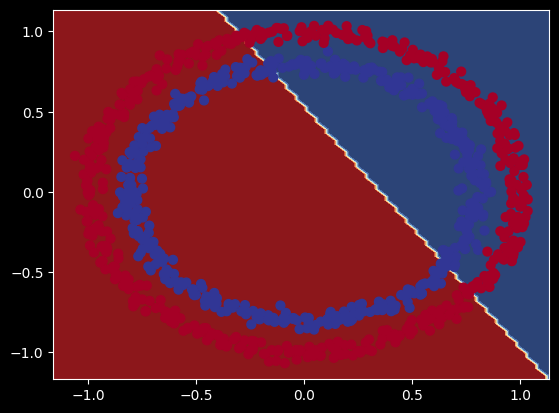

In [40]:
# Check out the predictions our model is making
plot_decision_boundry(model=model_3,X=X, y=y)

In [41]:
# Let's see if our model can be used for regression problem...
tf.random.set_seed(42)

# Create some regression data
X_regression = tf.range(0, 1000, 5)
y_regression = tf.range(100, 1100, 5) # y = X + 100

# Split our regression data into training and test sets
X_reg_train = X_regression[:150]
X_reg_test = X_regression[150:]

y_reg_train = y_regression[:150]
y_reg_test = y_regression[150:]

# Fit our model to regression data

model_3.fit(tf.expand_dims(X_reg_train, axis=-1),
            y_reg_train,
            epochs = 100)


Epoch 1/100


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense_9" is incompatible with the layer: expected axis -1 of input shape to have value 2, but received input with shape (None, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=int32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

Oh! wait... we compiled our model for binary classification problem.

But... we're now working on a regression problem let's change the model to suit our data.

In [42]:
# set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_4.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

# 3. Fit the model
X_reg_train_exp = tf.expand_dims(X_reg_train, axis=-1)
model_4.fit(X_reg_train_exp, y_reg_train, epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 379.6492 - mae: 379.6492  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 294.9507 - mae: 294.9507 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 207.4954 - mae: 207.4954 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 116.1725 - mae: 116.1725 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 49.2047 - mae: 49.2047 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 71.6465 - mae: 71.6465 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 69.6585 - mae: 69.6585 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.6556 - mae: 48.6556 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.5608 - mae: 46.5608 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.3598 - mae: 45.3598 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42.2915 - mae: 42.2915 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.0179 - mae: 43.0179 
Epoch 13/100
5/5

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


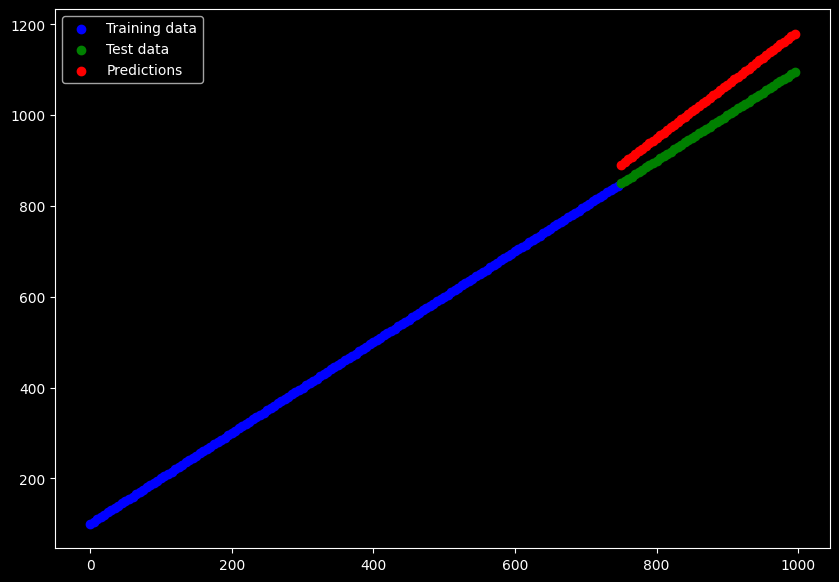

In [43]:
# Make predictions with our trained model
y_reg_pred = model_4.predict(X_reg_test)

# Plot the models predictions against our regression data
plt.figure(figsize = (10,7))
plt.scatter(X_reg_train, y_reg_train, c="b", label= "Training data")
plt.scatter(X_reg_test, y_reg_test, c="g", label = "Test data")
plt.scatter(X_reg_test, y_reg_pred, c ="r", label = "Predictions")
plt.legend()

# The missing piece Non-linearity

In [44]:
import matplotlib.pyplot as plt
import tensorflow as tf
tf.__version__

'2.21.0'

In [45]:

# set the random seed
tf.random.set_seed(42)


# create the model
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)

])

# compile the model
model_5.compile(loss = "binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4860 - loss: 6.4846   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 6.4672 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 6.4648 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 6.4635 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4830 - loss: 6.4624 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4840 - loss: 6.4406 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4840 - loss: 6.4360 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4850 - loss: 6.4256 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4860 - loss: 6.3585 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4870 - loss: 6.3394 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4870 - loss: 6.3349 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

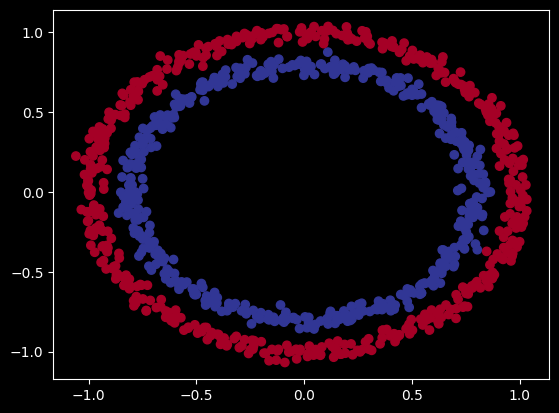

In [48]:
# Check out our data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step
Doing binary classification


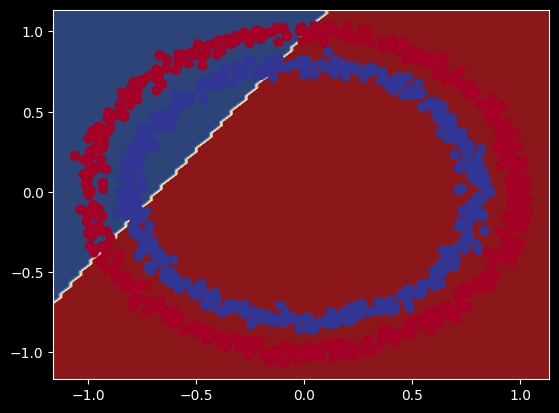

In [49]:
# Check the decision boundary
plot_decision_boundry(model_5, X,y)

In [50]:
import tensorflow as tf

In [51]:
# Time to replicate the multi-layer neural network from TensorFlow Playground

# Set the random seed
tf.random.set_seed(42)

# Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])


# 2. Compile the model
model_7.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history = model_7.fit(X,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5000 - loss: 5.7296   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 4.1418 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 3.5081 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 2.7668 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.2960 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.1005 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.0688 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.0424 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 1.0184 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.9940 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5000 - loss: 0.9706 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [52]:
# Evaluate the model
model_7.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5250 - loss: 0.6813 


[0.6813282370567322, 0.5249999761581421]

In [53]:
# Set the random seed
tf.random.set_seed(42)

# Create the model
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation= tf.keras.activations.sigmoid)
])


# 2. Compile the model
model_8.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history = model_8.fit(X,y,epochs=150)

Epoch 1/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5020 - loss: 0.7168   
Epoch 2/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 0.7097 
Epoch 3/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4820 - loss: 0.7050 
Epoch 4/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4840 - loss: 0.7019 
Epoch 5/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4770 - loss: 0.6998 
Epoch 6/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4800 - loss: 0.6981 
Epoch 7/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4680 - loss: 0.6966 
Epoch 8/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4490 - loss: 0.6947 
Epoch 9/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5220 - loss: 0.6921 
Epoch 10/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5500 - loss: 0.6914 
Epoch 11/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5470 - loss: 0.6907 
Epoch 12/150
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [54]:
# evaluate our model
model_8.evaluate(X,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9790 - loss: 0.1806 


[0.1806250363588333, 0.9789999723434448]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step
Doing binary classification


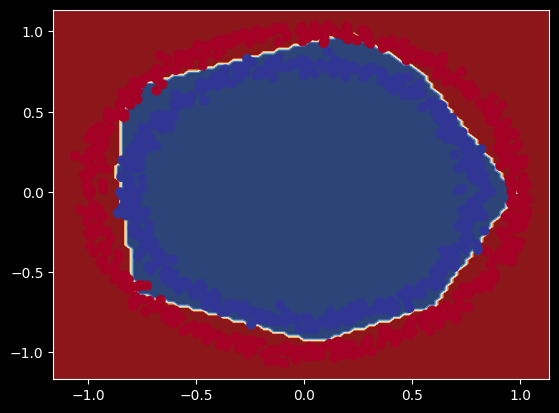

In [55]:
plot_decision_boundry(model_8, X,y)

🤔** Question :** What's wrong the predictions we've made? Are
we really evaluating our model correctly? Hint: what data did
the model learn on and what data did we predict on?

🗝️** Note: ** The combination of ** linear (straight lines) and
non-linear (non-straight lines) functions ** is one of the key
fundamentals of neural networks.

Now we've discussed the concept of linear and non-linear
functions (or lines), let's see them in action.

In [56]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [57]:
# Create a toy tensor (similar to the data we pass into our models)
A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

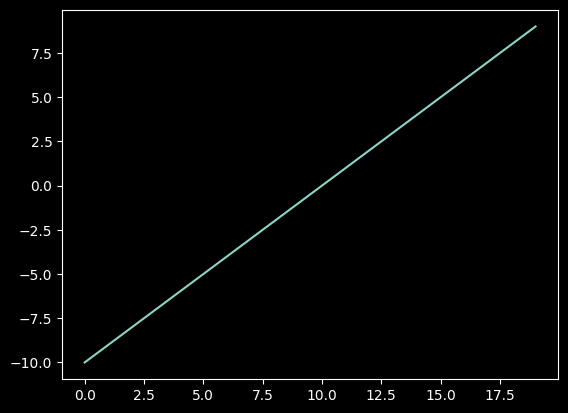

In [58]:
# Visualize our toy tensor
plt.plot(A)

In [59]:
# Let's start by replicating sigmoid - sigmoid(x) = 1 / (1 + exp(-x))
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

print(A)
#Use the sigmoid function on our toy tensor
print(sigmoid(A))


tf.Tensor(
[-10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.], shape=(20,), dtype=float32)
tf.Tensor(
[4.5397872e-05 1.2339458e-04 3.3535014e-04 9.1105117e-04 2.4726233e-03
 6.6928510e-03 1.7986210e-02 4.7425874e-02 1.1920292e-01 2.6894143e-01
 5.0000000e-01 7.3105860e-01 8.8079703e-01 9.5257413e-01 9.8201376e-01
 9.9330717e-01 9.9752742e-01 9.9908900e-01 9.9966466e-01 9.9987662e-01], shape=(20,), dtype=float32)


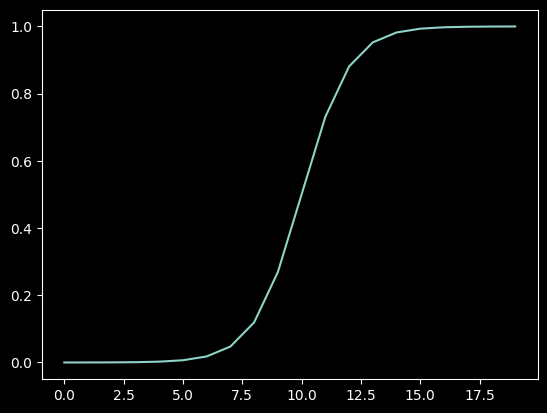

In [60]:
# Plot our toy tensor transformed by sigmoid
plt.plot(sigmoid(A))

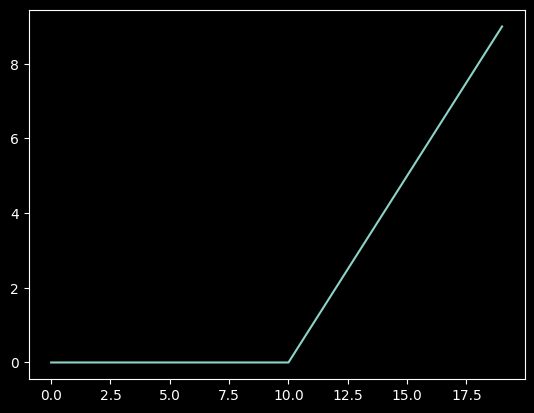

In [61]:
#Let's recreate relu function

def relu(x):
    return [max(i,0) for i in x]

plt.plot(relu(A))

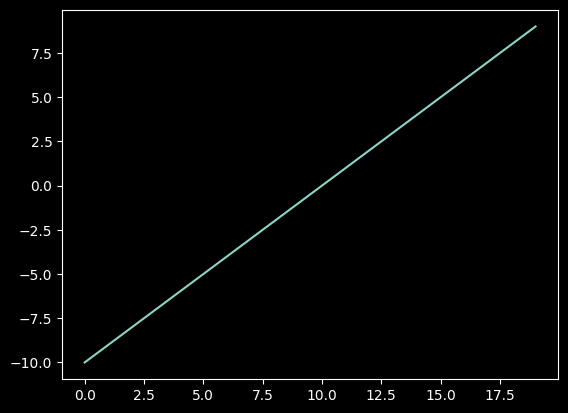

In [62]:
plt.plot(tf.keras.activations.linear(A))

In [63]:
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

## Evaluating and improving our classification
So far we've been training and testing on the same dataset...

However, in machine learning this is basically sin.

So let's create a training and test set.

In [64]:
# Check how many examples we have
len(X)

1000

In [65]:
#Split into train and test sets

X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [66]:
# Let's recreate a model to fit and training data and evaluate on the testing data

#set random seat
tf.random.set_seed(42)


# 1. Create the model (same as model_7)
model_9 =  tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


# 2. Compile the model
model_9.compile(
    loss = "binary_crossentropy",
    optimizer= tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"])


# 3. Fit the model
history = model_9.fit(X_train,y_train,epochs=25)

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4913 - loss: 0.6935
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5263 - loss: 0.6889 
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5312 - loss: 0.6860 
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5312 - loss: 0.6838 
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5312 - loss: 0.6816 
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5387 - loss: 0.6789 
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5425 - loss: 0.6751 
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5462 - loss: 0.6711 
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5575 - loss: 0.6666 
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6125 - loss: 0.6620 
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6187 - loss: 0.6573 
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0

In [67]:
# Evaluate the model on the test dataset
model_9.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6750 - loss: 0.5764 


[0.5763558745384216, 0.675000011920929]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step
Doing binary classification


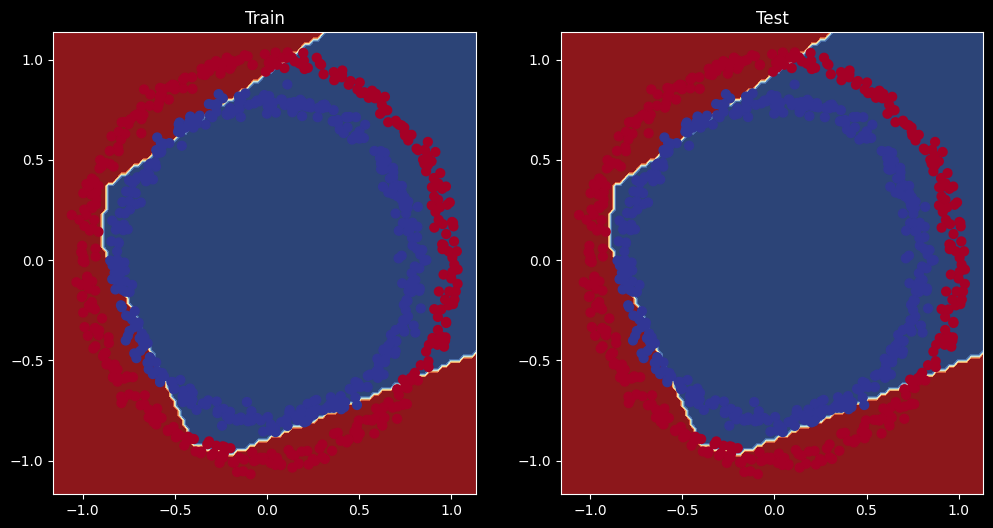

In [68]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundry(model_9, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundry(model_9, X_train, y_train)
plt.show()

In [69]:
# convert the history object into a DataFrame
import pandas as pd

pd.DataFrame(history.history)

,accuracy,loss
0,0.49125,0.693539
1,0.52625,0.688899
2,0.53125,0.685968
3,0.53125,0.683779
4,0.53125,0.681638
5,0.53875,0.678906
6,0.54250,0.675097
7,0.54625,0.671146
8,0.55750,0.666632
9,0.61250,0.662002


Text(0.5, 1.0, 'model_9 loss curves')

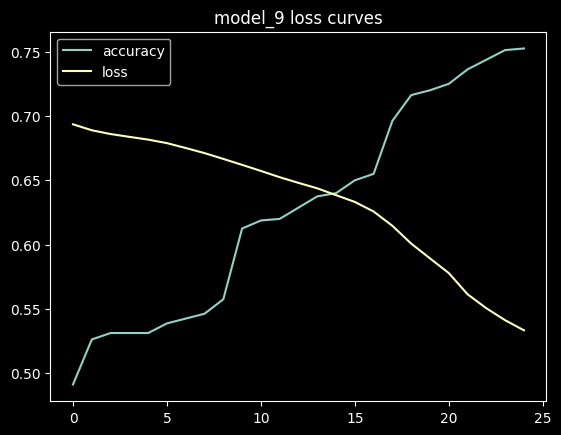

In [70]:
pd.DataFrame(history.history).plot()
plt.title("model_9 loss curves")

I🗝️ **Note:** For many problems, the loss function going down means the model is improving (It's making are getting closer to the ground truth labels.)

## Finding the best learning rate

To find the ideal learning rate (the learning rate were the loss decrease the most during training) We're Going to use the following steps:

* A learning rate **callback** -  You can't think of a callback as an extra piece of functionality you can add to your *while* it's training

* Another model (we could use the same one as above but we are practicing building models here)

* A modified Lost Curves plot.


In [71]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as model_9)
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="relu"),
])

# Compile the model
model_10.compile(
    loss = "binary_crossentropy",
    optimizer="Adam",
    metrics=["accuracy"]
)

# Create a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10** (epoch/20))


# Fit the model (Passing lr_scheduler callback)
history_10 = model_10.fit(
    X_train,
    y_train,
    epochs=100,
    callbacks=[lr_scheduler]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4988 - loss: 6.1032 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 6.0230 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.9897 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.8868 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.7652 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.6006 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.4091 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 5.0309 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4988 - loss: 4.7802 - learning_

<Axes: xlabel='epochs'>

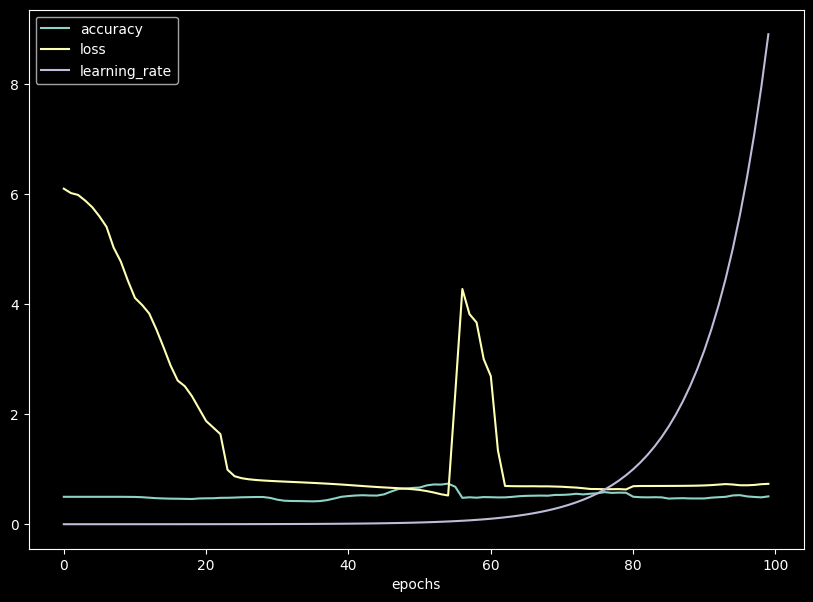

In [72]:
# Check out the history
pd.DataFrame(history_10.history).plot(figsize=(10,7), xlabel = "epochs")

Text(0.5, 1.0, 'Learning rate vs. Loss')

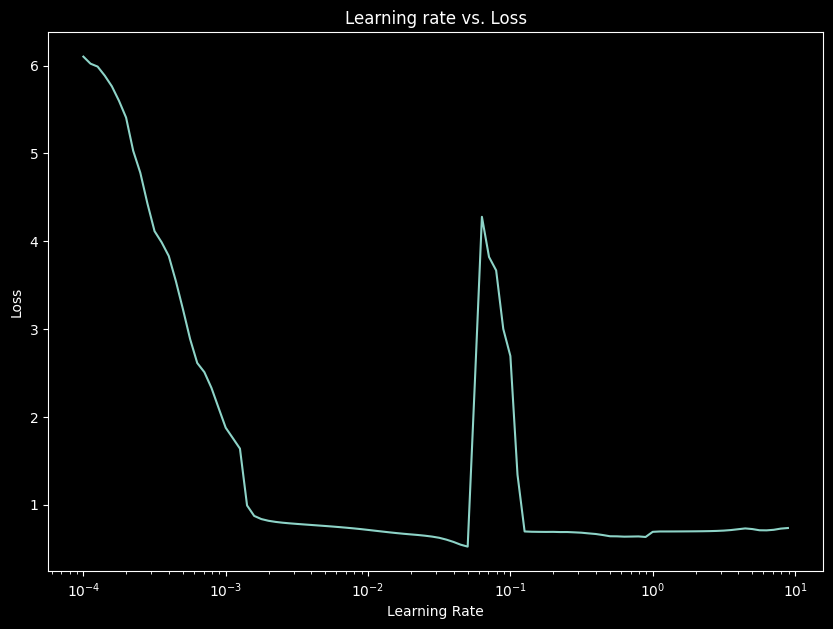

In [74]:
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10,7))
plt.semilogx(lrs, history_10.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. Loss")


In [75]:
# Examples of other typical learning rates values:
10**0, 10**-1, 10 ** -2, 10**-3, 1e-4

(1, 0.1, 0.01, 0.001, 0.0001)

---
